# Olist - A Brazilian E-Commerce Database

I choose to focus on the customers, orders, and order_items tables from the Olist database because they form the core transactional engine of the e-commerce business.

This EDA starts with loading the data, then combines SQL and Python to query and vizualize the data to answer 3 key questions:

Question 1: What is our monthly sales growth trend, and are we losing money on canceled orders?

Question 2: Which geographic states are driving revenue, and do they have different purchasing power?

Question 3: Are multi-item orders worth encouraging, or do shipping costs penalize larger baskets?



---



First I loaded the CSV files onto my drive and connected the notebook to pull from it

In [7]:
from google.colab import drive
import os

# Mount Google Drive to the Colab environment
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
import sqlite3
import pandas as pd


base_path = "/content/drive/MyDrive/OlistData/"


customers_df = pd.read_csv(os.path.join(base_path, "olist_customers_dataset.csv"))
orders_df = pd.read_csv(os.path.join(base_path, "olist_orders_dataset.csv"))
items_df = pd.read_csv(os.path.join(base_path, "olist_order_items_dataset.csv"))

# Build the database file directly inside drive folder
db_path = os.path.join(base_path, "olist_analysis.db")
conn = sqlite3.connect(db_path)


customers_df.to_sql('customers', conn, if_exists='replace', index=False)
orders_df.to_sql('orders', conn, if_exists='replace', index=False)
items_df.to_sql('order_items', conn, if_exists='replace', index=False)

conn.close()


In [9]:

!pip install jupysql --quiet
%load_ext sql

# Connect Jupysql directly to the database file in your Drive folder
%config SqlMagic.autopandas = True
%sql sqlite:////content/drive/MyDrive/OlistData/olist_analysis.db

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.1/95.1 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.8/192.8 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.9/296.9 kB 26.3 MB/s eta 0:00:00


Connecting to 'sqlite:////content/drive/MyDrive/OlistData/olist_analysis.db'

Then I did a very highlevel analysis of what each table is comprised of using SQL

In [10]:
%%sql
SELECT
    COUNT(DISTINCT order_id) as total_orders,
    MIN(order_purchase_timestamp) as earliest_order_date,
    MAX(order_purchase_timestamp) as latest_order_date,
    COUNT(DISTINCT customer_id) as total_customer_relationships
FROM orders;

Running query in 'sqlite:////content/drive/MyDrive/OlistData/olist_analysis.db'

,total_orders,earliest_order_date,latest_order_date,total_customer_relationships
0,99441,2016-09-04 21:15:19,2018-10-17 17:30:18,99441


In [11]:
%%sql
Select *
From customers
Limit 10

Running query in 'sqlite:////content/drive/MyDrive/OlistData/olist_analysis.db'

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP
5,879864dab9bc3047522c92c82e1212b8,4c93744516667ad3b8f1fb645a3116a4,89254,jaragua do sul,SC
6,fd826e7cf63160e536e0908c76c3f441,addec96d2e059c80c30fe6871d30d177,4534,sao paulo,SP
7,5e274e7a0c3809e14aba7ad5aae0d407,57b2a98a409812fe9618067b6b8ebe4f,35182,timoteo,MG
8,5adf08e34b2e993982a47070956c5c65,1175e95fb47ddff9de6b2b06188f7e0d,81560,curitiba,PR
9,4b7139f34592b3a31687243a302fa75b,9afe194fb833f79e300e37e580171f22,30575,belo horizonte,MG


In [12]:
%%sql
Select *
From order_items
Limit 10

Running query in 'sqlite:////content/drive/MyDrive/OlistData/olist_analysis.db'

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14
5,00048cc3ae777c65dbb7d2a0634bc1ea,1,ef92defde845ab8450f9d70c526ef70f,6426d21aca402a131fc0a5d0960a3c90,2017-05-23 03:55:27,21.90,12.69
6,00054e8431b9d7675808bcb819fb4a32,1,8d4f2bb7e93e6710a28f34fa83ee7d28,7040e82f899a04d1b434b795a43b4617,2017-12-14 12:10:31,19.90,11.85
7,000576fe39319847cbb9d288c5617fa6,1,557d850972a7d6f792fd18ae1400d9b6,5996cddab893a4652a15592fb58ab8db,2018-07-10 12:30:45,810.00,70.75
8,0005a1a1728c9d785b8e2b08b904576c,1,310ae3c140ff94b03219ad0adc3c778f,a416b6a846a11724393025641d4edd5e,2018-03-26 18:31:29,145.95,11.65
9,0005f50442cb953dcd1d21e1fb923495,1,4535b0e1091c278dfd193e5a1d63b39f,ba143b05f0110f0dc71ad71b4466ce92,2018-07-06 14:10:56,53.99,11.40


In [13]:
%%sql
Select *
From orders
Limit 10


Running query in 'sqlite:////content/drive/MyDrive/OlistData/olist_analysis.db'

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01 00:00:00
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,None,None,2017-05-09 00:00:00
7,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07 00:00:00
8,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,delivered,2017-01-23 18:29:09,2017-01-25 02:50:47,2017-01-26 14:16:31,2017-02-02 14:08:10,2017-03-06 00:00:00
9,e69bfb5eb88e0ed6a785585b27e16dbf,31ad1d1b63eb9962463f764d4e6e0c9d,delivered,2017-07-29 11:55:02,2017-07-29 12:05:32,2017-08-10 19:45:24,2017-08-16 17:14:30,2017-08-23 00:00:00


# Question 1: What is our monthly sales growth trend, and are we losing money on canceled orders?





Running query in 'sqlite:////content/drive/MyDrive/OlistData/olist_analysis.db'

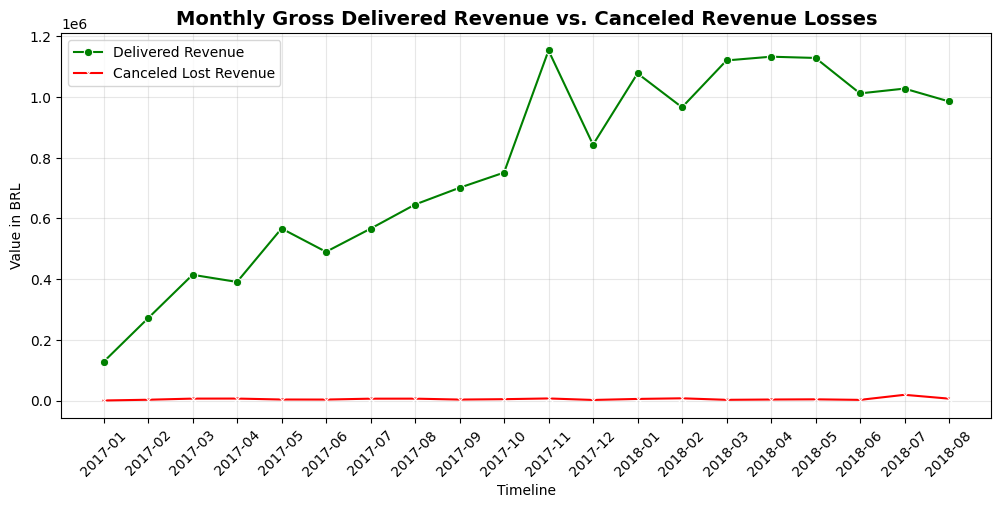

In [14]:
# Aggregate monthly gross revenue vs. canceled revenue
revenue_trends = %sql \
SELECT \
    SUBSTR(o.order_purchase_timestamp, 1, 7) as year_month, \
    SUM(CASE WHEN o.order_status = 'delivered' THEN (i.price + i.freight_value) ELSE 0 END) as delivered_revenue, \
    SUM(CASE WHEN o.order_status = 'canceled' THEN (i.price + i.freight_value) ELSE 0 END) as canceled_lost_revenue \
FROM orders o \
JOIN order_items i ON o.order_id = i.order_id \
WHERE year_month BETWEEN '2017-01' AND '2018-08' \
GROUP BY year_month \
ORDER BY year_month;

# Python: Plot a dual line chart to visualize the growth vs loss gap
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))
sns.lineplot(data=revenue_trends, x='year_month', y='delivered_revenue', marker='o', color='green', label='Delivered Revenue')
sns.lineplot(data=revenue_trends, x='year_month', y='canceled_lost_revenue', marker='x', color='red', label='Canceled Lost Revenue')

plt.title('Monthly Gross Delivered Revenue vs. Canceled Revenue Losses', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.ylabel('Value in BRL')
plt.xlabel('Timeline')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

We observe that delivered revenue scales dramatically up throughout 2017, proving the marketplace has strong product-market fit.

**Recommendation:** Because the Canceled Revenue line remains flat and close to zero, the fulfillment system is highly stable and the company does not need to focus on a churn strategy for now; they should keep focusing resources entirely on customer acquisition.



---



# Question 2: Which geographic states are driving our revenue, and do they have different purchasing power?





Running query in 'sqlite:////content/drive/MyDrive/OlistData/olist_analysis.db'

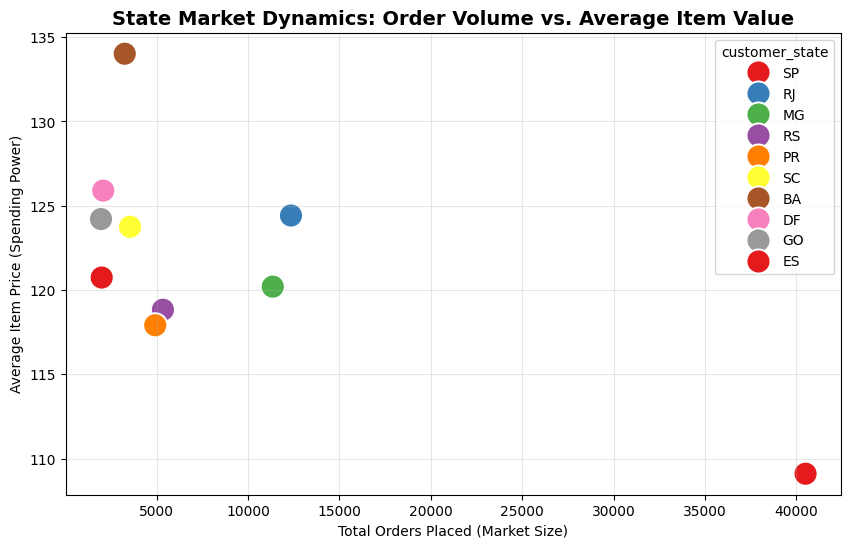

In [15]:
# Aggregate order count, total revenue, and average order value by state
geo_revenue = %sql \
SELECT \
    c.customer_state, \
    COUNT(DISTINCT o.order_id) as total_orders, \
    ROUND(SUM(i.price), 2) as net_item_revenue, \
    ROUND(AVG(i.price), 2) as average_item_value \
FROM orders o \
JOIN customers c ON o.customer_id = c.customer_id \
JOIN order_items i ON o.order_id = i.order_id \
WHERE o.order_status = 'delivered' \
GROUP BY c.customer_state \
ORDER BY net_item_revenue DESC \
LIMIT 10;

# Scatter plot comparing market volume vs spending depth
plt.figure(figsize=(10, 6))
sns.scatterplot(data=geo_revenue, x='total_orders', y='average_item_value', hue='customer_state', s=300, palette='Set1')

plt.title('State Market Dynamics: Order Volume vs. Average Item Value', fontsize=14, fontweight='bold')
plt.xlabel('Total Orders Placed (Market Size)')
plt.ylabel('Average Item Price (Spending Power)')
plt.grid(True, alpha=0.3)
plt.show()

SP (São Paulo) dominates overall transaction counts and net revenue. However, looking at average_item_value, smaller peripheral states have a higher average basket cost per item.

**Recommendation:** The marketing team can run a dual-strategy framework. SP is our high-volume market, so we can keep running baseline brand awareness there. For states with higher average item values but lower overall counts, run targeted email campaigns pushing premium product bundles since those consumers are willing to spend more per transaction.



---



# Question 3: Are multi-item orders worth encouraging, or do shipping costs penalize larger baskets?



Running query in 'sqlite:////content/drive/MyDrive/OlistData/olist_analysis.db'

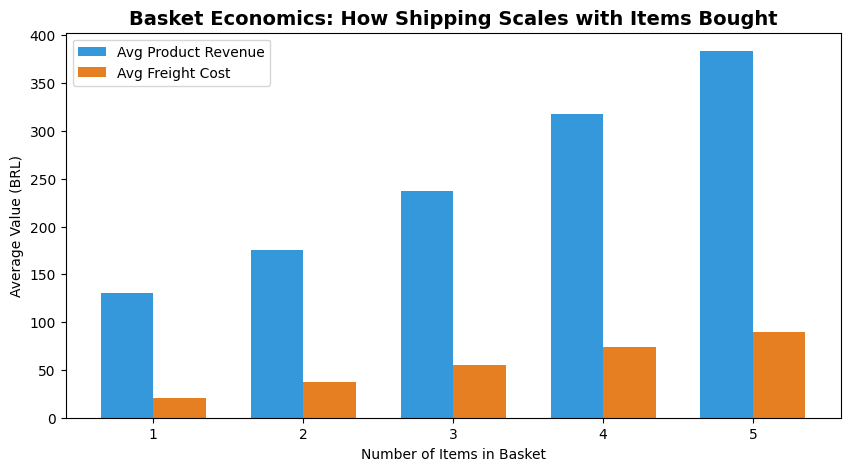

In [16]:
# Group metrics by the size of the user's basket
basket_economics = %sql \
SELECT \
    items_in_basket, \
    COUNT(order_id) as order_volume, \
    AVG(total_items_price) as avg_item_revenue, \
    AVG(total_freight) as avg_freight_cost \
FROM ( \
    SELECT \
        order_id, \
        COUNT(order_item_id) as items_in_basket, \
        SUM(price) as total_items_price, \
        SUM(freight_value) as total_freight \
    FROM order_items \
    GROUP BY order_id \
) \
WHERE items_in_basket <= 5 \
GROUP BY items_in_basket;

# Bar chart to compare revenue vs. shipping scaling
import numpy as np

x = np.arange(len(basket_economics['items_in_basket']))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, basket_economics['avg_item_revenue'], width, label='Avg Product Revenue', color='#3498db')
ax.bar(x + width/2, basket_economics['avg_freight_cost'], width, label='Avg Freight Cost', color='#e67e22')

ax.set_title('Basket Economics: How Shipping Scales with Items Bought', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Items in Basket')
ax.set_ylabel('Average Value (BRL)')
ax.set_xticks(x)
ax.set_xticklabels(basket_economics['items_in_basket'])
ax.legend()
plt.show()

The freight cost scales linearly, meaning the platform does not bundle shipping efficiently for multi-item orders (ordering more does not mean cheaper shipping)

**Recommendation:** If shipping scales aggressively with basket size, it penalizes cross-selling. The product team should redesign vendor fulfillment logic to allow sellers to ship multi-item packages in a single box, lowering the shipping barrier and encouraging users to buy more items per checkout session.